# EDA
This is the first notebook - I am getting familiar with the data and tables. Cleaning a little bit and exporting the data for the next notebook (feature engineering). At the end, I want to cluster the data and visualize what I found out.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from debugpy.common import timestamp

In [2]:
flights = pd.read_csv('raw_data/flights_filtered.csv')
hotels = pd.read_csv('raw_data/hotels_filtered.csv')
users = pd.read_csv('raw_data/Users_filtered.csv')
sessions= pd.read_csv('raw_data/Sessions_filtered.csv')

### generally looking at the tables

In [3]:
print(flights.duplicated().sum(),hotels.duplicated().sum(),users.duplicated().sum(),sessions.duplicated().sum())

0 0 0 0


# Sessions

In [4]:
sessions.head()

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,648852-87415b144daa4f4d93a5cef1cf5dc582,648852,NaN,2023-03-17 17:22:00,2023-03-17 17:23:15,True,True,0.2,0.1,False,False,10,False
1,651269-61ce23b822c04a6e86d13ba33826dd3e,651269,651269-e9461ea9d60946549e665aa5ab818f1d,2023-03-17 21:32:00,2023-03-17 21:35:15,False,False,NaN,NaN,True,True,27,False
2,651613-5be2f8b2dd5a4dbcb6cd4ff0247fff2b,651613,651613-1acf724812d44470947dcab57872dd0f,2023-03-17 11:50:00,2023-03-17 11:53:27,False,False,NaN,NaN,True,True,28,False
3,653228-a6cf39a1619a42199f05ee8d33b9547b,653228,NaN,2023-03-17 14:14:00,2023-03-17 14:15:50,False,False,NaN,NaN,False,False,15,False
4,653281-6ec2b5f4c5fe48288e7c8e51ef78f6ce,653281,NaN,2023-03-17 14:57:00,2023-03-17 14:57:40,False,False,NaN,NaN,False,False,5,False


In [5]:
#Question: Is it possible to delete flight discount & hotel discount, becuase the information is already in the amount column?
sessions[~(~sessions[["flight_discount_amount", "hotel_discount_amount"]].isna().values == sessions[["flight_discount", "hotel_discount"]].values).all(axis=1)]

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
10148,101486-46912e06b8f94b949f46af20eb097f8f,101486,101486-29a51199b1a748da8c45d3d2fc9c691a,2022-03-26 20:08:22,2022-03-26 22:08:22,True,True,NaN,NaN,True,True,156,True
10149,118043-e476985728a741d7a96ea1dcf55963e6,118043,118043-2c1b2e17eb1147e184b00be13725d0fd,2022-04-22 09:38:27,2022-04-22 10:04:44.411729,True,True,NaN,NaN,True,True,26,True
10150,153982-0a2c4b9c37594cca8019068acedd878a,153982,153982-5ee3beaabece462ba68982ef4f8e3a23,2022-07-08 13:15:40,2022-07-08 14:20:35.612564,True,True,NaN,NaN,True,True,64,True
10151,174997-d37e4081489646fc891296f5e21b96f1,174997,174997-a7c3a96620594e849a2345ac4e0bd45d,2023-01-05 20:17:50,2023-01-05 22:17:50,True,True,NaN,NaN,True,True,155,True
10152,181157-4689176bf8e2444f928c77739c75c713,181157,181157-259acaefcd924050bd6640f049eded1a,2022-05-23 20:16:04,2022-05-23 22:16:04,True,True,NaN,NaN,True,True,200,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34813,694265-74b2a86e73854afea04cd84b1a1d10e3,694265,694265-442d6499b511481786add276f620d4fc,2023-07-26 21:37:49,2023-07-26 22:30:14.467636,True,True,NaN,NaN,True,True,52,True
34814,589228-c82de5b13d8d4739aeb90e2ca924d2e0,589228,589228-7cbd8bd73eed4c549a0074919e71fdc8,2023-07-20 21:01:17,2023-07-20 21:45:04.905844,True,True,NaN,NaN,True,True,43,True
34815,671151-fa865fb0bf8249aeb164408b470322d2,671151,671151-a25acb9062764a168fbd4286d15d57fd,2023-07-24 17:45:47,2023-07-24 18:09:14.839854,True,True,NaN,NaN,True,True,23,True
34816,609393-17fa2042385e48faac6ab20586749340,609393,609393-b92d487037ec447db1e3ddf977709a52,2023-07-21 21:02:05,2023-07-21 21:27:18.179946,True,True,NaN,NaN,True,True,25,True


→ Error in the data: there are rows, that say there are discounts, but there is no amount
→ assumption: error in amount, not in True/False column. So I am filling in the False NaN values with the mean

In [6]:
mean_flight = sessions["flight_discount_amount"].mean()
mean_hotel = sessions["hotel_discount_amount"].mean()

In [7]:
#filling in the values with .loc
mask = sessions["flight_discount_amount"].isna() & (sessions["flight_discount"] == True)
sessions.loc[mask, "flight_discount_amount"] = mean_flight

mask = sessions["hotel_discount_amount"].isna() & (sessions["hotel_discount"] == True)
sessions.loc[mask, "hotel_discount_amount"] = mean_hotel

In [8]:
#drop the axis we don't need anymore
sessions = sessions.drop(columns=['flight_discount','hotel_discount'])

In [9]:
sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 48683 entries, 0 to 48682
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              48683 non-null  str    
 1   user_id                 48683 non-null  int64  
 2   trip_id                 16778 non-null  str    
 3   session_start           48683 non-null  str    
 4   session_end             48683 non-null  str    
 5   flight_discount_amount  8784 non-null   float64
 6   hotel_discount_amount   6797 non-null   float64
 7   flight_booked           48683 non-null  bool   
 8   hotel_booked            48683 non-null  bool   
 9   page_clicks             48683 non-null  int64  
 10  cancellation            48683 non-null  bool   
dtypes: bool(3), float64(2), int64(2), str(4)
memory usage: 3.1 MB


Dtypes seem correct, but not session start/end. Changing that

In [10]:
sessions['session_start'] = pd.to_datetime(sessions['session_start'], format='mixed')
sessions['session_end'] = pd.to_datetime(sessions['session_end'], format='mixed')

In [11]:
#maybe interesting for feature engineering later:
#clicks per customer per session or per booking
#trips per user
#how many sessions per trip per user

<Axes: >

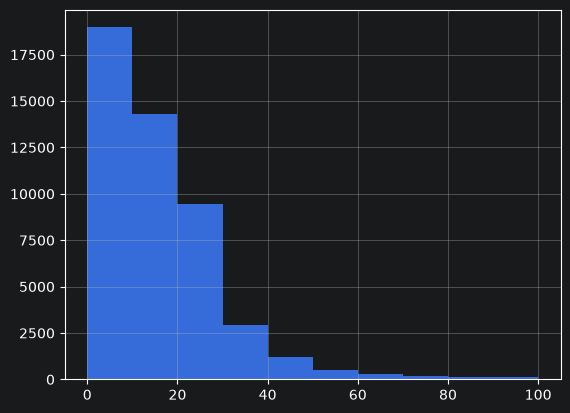

In [12]:
sessions['page_clicks'].hist(range=[0,100])

with a few hundred outliers above 100

In [13]:
#how many cancelled?
sessions['cancellation'].value_counts()

cancellation
False    48069
True       614
Name: count, dtype: int64

In [14]:
sessions.to_csv('preprocessed_data/sessions_preprocessed.csv', index=False)

# hotels

In [15]:
hotels.head()

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd
0,228872-47e5bd5e323748bb85e3a0944e6b6ad3,Banyan Tree - phoenix,4,1,2022-07-19 10:45:34.065,2022-07-23 11:00:00,107
1,440212-96a28edb355f4656b9c3ce40dc380339,Radisson - baltimore,1,2,2022-12-05 09:34:32.7,2022-12-06 11:00:00,115
2,446933-4273e6639af84810a800fa552fc8bdfd,Fairmont - new york,6,1,2022-12-14 11:00:00,2022-12-20 11:00:00,167
3,478760-840b3de1be6748bebe15747d340b556d,Banyan Tree - hamilton,5,2,2022-12-22 11:00:00,2022-12-27 11:00:00,174
4,443652-134aa9d023a54f63854c7e455754ba16,Shangri-La - austin,2,3,2022-12-30 13:33:33.345,2023-01-02 11:00:00,336


In [16]:
#assumption: hotel per room usd is also per night
#check out time is always 11 o'clock, but check In time is personalized
#nights isn't always right -> -2 and 0 nights

In [17]:
#for the new column
hotels['check_in_time']=pd.to_datetime(hotels['check_in_time'], format='mixed')
hotels['check_out_time']=pd.to_datetime(hotels['check_out_time'], format='mixed')

In [18]:
hotels["checkin_weekday"] = hotels["check_in_time"].dt.day_of_week
hotels["checkout_weekday"] = hotels["check_out_time"].dt.day_of_week

In [19]:
hotels.head()

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,checkin_weekday,checkout_weekday
0,228872-47e5bd5e323748bb85e3a0944e6b6ad3,Banyan Tree - phoenix,4,1,2022-07-19 10:45:34.065,2022-07-23 11:00:00,107,1,5
1,440212-96a28edb355f4656b9c3ce40dc380339,Radisson - baltimore,1,2,2022-12-05 09:34:32.700,2022-12-06 11:00:00,115,0,1
2,446933-4273e6639af84810a800fa552fc8bdfd,Fairmont - new york,6,1,2022-12-14 11:00:00.000,2022-12-20 11:00:00,167,2,1
3,478760-840b3de1be6748bebe15747d340b556d,Banyan Tree - hamilton,5,2,2022-12-22 11:00:00.000,2022-12-27 11:00:00,174,3,1
4,443652-134aa9d023a54f63854c7e455754ba16,Shangri-La - austin,2,3,2022-12-30 13:33:33.345,2023-01-02 11:00:00,336,4,0


In [20]:
#new nights column from check in/check out time
hotels["nights_new"] = (pd.to_datetime(hotels["check_out_time"].dt.date) - pd.to_datetime(hotels["check_in_time"].dt.date)).dt.days

In [85]:
hotels['nights_new'].value_counts()

nights_new
 2     3166
 3     2569
 4     1834
 1     1765
 5     1232
 6      844
 7      592
 8      412
 0      401
 9      345
 10     255
 11     215
 12     177
 13     104
 14      95
 15      76
 16      56
 17      43
 18      41
-1       29
 20      24
 21      19
 22      14
 19      10
 23       8
 24       6
 25       5
 26       5
 29       4
 28       4
 27       4
 34       3
 30       3
 35       2
 31       2
 32       2
 38       2
 36       1
 33       1
 42       1
 40       1
 47       1
 43       1
Name: count, dtype: int64

In [23]:
hotels[(hotels['nights_new'] <= 0) & (hotels['nights']>0)] #checking if the original data has values I can use

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,checkin_weekday,checkout_weekday,nights_new


In [86]:
# -1 has to be an error in the data and 401 entries with 0 nights too
# -> setting those rows to NaN: (also for 0) because I don't know where exactly the error is. Maybe I am going to detele them later, maybe I can use other information from those rows

hotels.loc[hotels['nights_new'] <= 0, ['check_in_time','check_out_time','nights_new']] = None

In [87]:
hotels['nights_new'].value_counts()

nights_new
2.0     3166
3.0     2569
4.0     1834
1.0     1765
5.0     1232
6.0      844
7.0      592
8.0      412
9.0      345
10.0     255
11.0     215
12.0     177
13.0     104
14.0      95
15.0      76
16.0      56
17.0      43
18.0      41
20.0      24
21.0      19
22.0      14
19.0      10
23.0       8
24.0       6
25.0       5
26.0       5
29.0       4
28.0       4
27.0       4
34.0       3
30.0       3
35.0       2
31.0       2
32.0       2
38.0       2
36.0       1
33.0       1
42.0       1
40.0       1
47.0       1
43.0       1
Name: count, dtype: int64

In [88]:
#dropping old nights column
hotels.drop('nights',axis=1, inplace=True)

<Axes: xlabel='nights_new', ylabel='Count'>

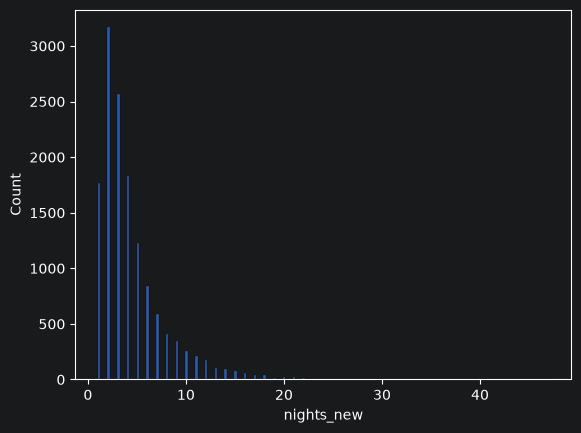

In [89]:
sns.histplot(hotels,x="nights_new")

<Axes: xlabel='hotel_per_room_usd', ylabel='Count'>

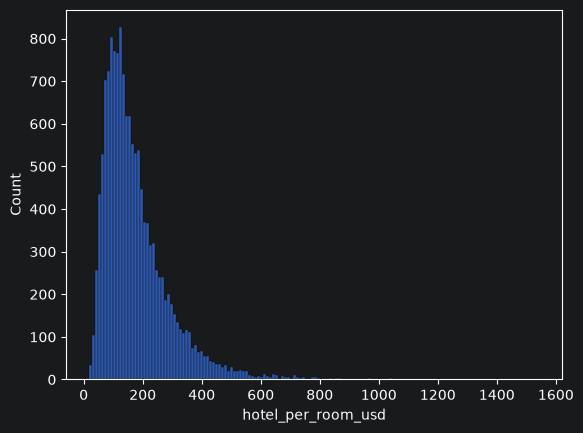

In [90]:
sns.histplot(hotels,x="hotel_per_room_usd")

<Axes: xlabel='checkin_weekday', ylabel='Count'>

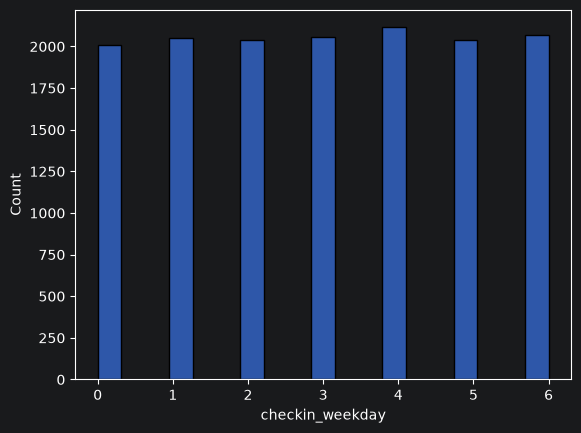

In [91]:
sns.histplot(hotels,x="checkin_weekday")

In [92]:
hotels.to_csv('preprocessed_data/hotels_preprocessed.csv', index=False)

# Flights

In [93]:
flights.head()

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,526901-0bb64144805e44419bd60af3f9bc4bb1,DAL,edmonton,YXD,1,True,2023-07-30 07:00:00,2023-08-02 07:00:00,0,Delta Air Lines,53.667,-113.467,476.00
1,635790-71504937f58f41158486c9ff024bfafe,BOS,portland,PDX,1,True,2023-07-29 11:00:00,2023-08-02 11:00:00,1,Delta Air Lines,45.589,-122.597,736.52
2,379543-786b5bc990ab42348075f170807f4625,SJC,tucson,TUS,1,True,2022-11-04 13:00:00,2022-11-07 13:00:00,1,JetBlue Airways,32.166,-110.883,207.16
3,408551-35b342c868fa4dcfae23554edc29491e,UGN,new york,JFK,2,True,2022-11-20 12:00:00,2022-11-24 12:00:00,0,Uzbekistan Airways,40.640,-73.779,427.94
4,417679-624d84164bc443e6bfc876d4a84d358c,LGA,louisville,LOU,3,True,2022-11-26 07:00:00,2022-11-29 07:00:00,0,American Airlines,38.228,-85.664,547.45


<Axes: xlabel='base_fare_usd', ylabel='Count'>

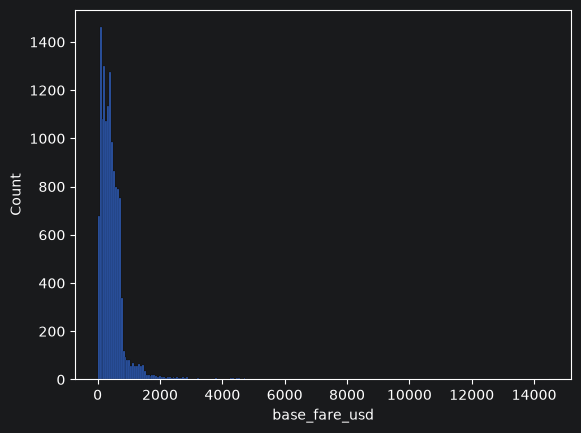

In [94]:
sns.histplot(flights, x="base_fare_usd")

In [95]:
flights['base_fare_usd'].describe()

count    13767.000000
mean       491.872990
std        678.151486
min          2.410000
25%        198.520000
50%        378.430000
75%        592.465000
max      14466.330000
Name: base_fare_usd, dtype: float64

there are outliers

In [96]:
#check for errors in seats:
flights['seats'].describe()
flights['seats'].value_counts()
#seems right

seats
1    11742
2     1487
3      384
4      123
5       18
6       11
7        1
8        1
Name: count, dtype: int64

In [97]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 13767 entries, 0 to 13766
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_id                  13767 non-null  str    
 1   origin_airport           13767 non-null  str    
 2   destination              13767 non-null  str    
 3   destination_airport      13767 non-null  str    
 4   seats                    13767 non-null  int64  
 5   return_flight_booked     13767 non-null  bool   
 6   departure_time           13767 non-null  str    
 7   return_time              13172 non-null  str    
 8   checked_bags             13767 non-null  int64  
 9   trip_airline             13767 non-null  str    
 10  destination_airport_lat  13767 non-null  float64
 11  destination_airport_lon  13767 non-null  float64
 12  base_fare_usd            13767 non-null  float64
dtypes: bool(1), float64(3), int64(2), str(7)
memory usage: 1.3 MB


In [98]:
flights['checked_bags'].describe()
#bags per seat mean?

count    13767.000000
mean         0.585240
std          0.654654
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: checked_bags, dtype: float64

In [99]:
#right format
flights['departure_time']= pd.to_datetime(flights['departure_time'])
flights['return_time']= pd.to_datetime(flights['return_time'])

In [100]:
#are there timetravelers?
(((flights['return_time']-flights['departure_time']).dt.days)<=0).sum()

np.int64(72)

In [101]:
#who are they in the dataframe
flights[(flights['return_time'] - flights['departure_time']).dt.days <= 0]

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
7,445515-8f3102fa5f8a4404a47bd59c5d8d4b74,YZD,los angeles,LAX,1,True,2022-12-14 09:00:00,2022-12-14 09:00:00,1,United Airlines,33.942,-118.408,623.86
89,530773-a3ff3259c7f740a0bd6519434c239cdf,YYC,houston,HOU,1,True,2023-01-23 07:00:00,2023-01-23 07:00:00,1,Southwest Airlines,29.607,-95.159,478.47
337,510960-f182f71070c34a6a92d509937db21000,TLH,charlotte,CLT,1,True,2023-05-21 07:00:00,2023-05-21 07:00:00,0,Delta Air Lines,35.214,-80.943,117.96
762,515423-46a9df24e760478ea44798cd8300caab,YYJ,quebec,YQB,1,True,2023-01-13 11:00:00,2023-01-13 11:00:00,0,Air Canada,46.788,-71.398,684.31
919,388947-d4438b9271784841ba137e2d90a99fd9,LGA,portland,PDX,1,True,2023-01-30 07:00:00,2023-01-30 07:00:00,1,Alitalia,45.589,-122.597,719.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12669,517105-3829f45198e643bd8715161541ff0aa1,SNA,washington,IAD,1,True,2023-05-05 07:00:00,2023-05-05 07:00:00,1,United Airlines,38.852,-77.037,628.77
12725,513826-1e0021d03640427ba802c9332841377b,BIF,philadelphia,PHL,1,True,2023-04-16 09:00:00,2023-04-16 09:00:00,0,American Airlines,39.872,-75.241,565.02
13233,538703-1789fc6808414078a8db0af41872fe01,BIF,winnipeg,YWG,3,True,2023-05-28 11:00:00,2023-05-28 11:00:00,0,KLM Royal Dutch Airlines,50.056,-97.032,1152.45
13548,541699-d6be31c26ca3405dad75018062d46ded,MOD,tucson,DMA,1,True,2023-07-16 09:00:00,2023-07-16 09:00:00,0,Delta Air Lines,32.166,-110.883,198.51


In [102]:
#=> e.g. Row 2: PWM to JFK takes a little more than 1 hour, there is no time difference between those cities.
# departure time is always the same as arrival time here (tested it with == 0), so there is either a mistake in the departure time or arrival time or both. I am deleting the times, so there will be NaNs, because I want to keep the information, that there was a booked flight. maybe I am going to delete it later
condition = (flights['return_time'] - flights['departure_time']).dt.days <= 0
flights.loc[condition, ['return_time', 'departure_time']] = None

In [103]:
flights.head()

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,526901-0bb64144805e44419bd60af3f9bc4bb1,DAL,edmonton,YXD,1,True,2023-07-30 07:00:00,2023-08-02 07:00:00,0,Delta Air Lines,53.667,-113.467,476.00
1,635790-71504937f58f41158486c9ff024bfafe,BOS,portland,PDX,1,True,2023-07-29 11:00:00,2023-08-02 11:00:00,1,Delta Air Lines,45.589,-122.597,736.52
2,379543-786b5bc990ab42348075f170807f4625,SJC,tucson,TUS,1,True,2022-11-04 13:00:00,2022-11-07 13:00:00,1,JetBlue Airways,32.166,-110.883,207.16
3,408551-35b342c868fa4dcfae23554edc29491e,UGN,new york,JFK,2,True,2022-11-20 12:00:00,2022-11-24 12:00:00,0,Uzbekistan Airways,40.640,-73.779,427.94
4,417679-624d84164bc443e6bfc876d4a84d358c,LGA,louisville,LOU,3,True,2022-11-26 07:00:00,2022-11-29 07:00:00,0,American Airlines,38.228,-85.664,547.45


In [104]:
flights.to_csv('preprocessed_data/flights_preprocessed.csv', index=False)

# Users

In [105]:
users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10
...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06


In [106]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5782 non-null   int64  
 1   birthdate         5782 non-null   str    
 2   gender            5782 non-null   str    
 3   married           5782 non-null   bool   
 4   has_children      5782 non-null   bool   
 5   home_country      5782 non-null   str    
 6   home_city         5782 non-null   str    
 7   home_airport      5782 non-null   str    
 8   home_airport_lat  5782 non-null   float64
 9   home_airport_lon  5782 non-null   float64
 10  sign_up_date      5782 non-null   str    
dtypes: bool(2), float64(2), int64(1), str(6)
memory usage: 418.0 KB


In [107]:
users['birthdate'] = pd.to_datetime(users['birthdate'])
users['sign_up_date'] = pd.to_datetime(users['sign_up_date'])

In [108]:
#when were they born and how old are they?
#users['birthdate'].dt.year.hist() #no errors
#new column for age:
users["Age"] = ((pd.Timestamp.now() - pd.to_datetime(users["birthdate"]))/365.25).dt.days

In [109]:
print(users['gender'].value_counts(),users['married'].value_counts(),users['has_children'].value_counts())

gender
F    5118
M     653
O      11
Name: count, dtype: int64 married
False    3226
True     2556
Name: count, dtype: int64 has_children
False    3896
True     1886
Name: count, dtype: int64


In [110]:
users["days_in"] = (pd.Timestamp.now() - pd.to_datetime(users["sign_up_date"])).dt.days

In [111]:
users.to_csv('preprocessed_data/users_preprocessed.csv', index=False)